# Machine Learning project

**GOURDON HUET Antoine / Mehdi / Nathan**

---


### Topic and problematic :

We chose the subject of **music**, after a vote, it was the subject that entertains all 3 of us, and we thought that being entertained by the subject is the best way to work efficiently on it without being bored.  
Music is a part of everyone’s life, especially for us since we listen to it **everyday**.  
But what makes a song be “listenable”? Are they parameters that make a song less or more good?  
**Can we predict if a music will be judged as good by people simply by working on its components?**

This question came in our mind, it would be surprisingly interesting if we could predict if a song will be popular or not.  
We searched for a dataset and found a Kaggle with a huge dataset, and great variables such as **acousticness**, **danceability**, **energy**, **liveness** and more.  [**Song Popularity Dataset**](https://www.kaggle.com/datasets/yasserh/song-popularity-dataset/data)

We agreed on building our own project, our goal is to create an optimal algorithm.

---

In [1]:
import math
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


## Exploration Data Analysis

In [2]:
df = pd.read_csv('song_data.csv')

# song_name is a unique string identifier
df.drop(['song_name'], axis=1, inplace=True)

display(df.head())

target = 'song_popularity'
features = [i for i in df.columns if i not in [target]]
original_df = df.copy(deep=True)

print('\nThe Dataset consists of {} features & {} samples.'.format(df.shape[1], df.shape[0]))

,song_popularity,song_duration_ms,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,audio_mode,speechiness,tempo,time_signature,audio_valence
0,73,262333,0.005520,0.496,0.682,0.000029,8,0.0589,-4.095,1,0.0294,167.060,4,0.474
1,66,216933,0.010300,0.542,0.853,0.000000,3,0.1080,-6.407,0,0.0498,105.256,4,0.370
2,76,231733,0.008170,0.737,0.463,0.447000,0,0.2550,-7.828,1,0.0792,123.881,4,0.324
3,74,216933,0.026400,0.451,0.970,0.003550,0,0.1020,-4.938,1,0.1070,122.444,4,0.198
4,56,223826,0.000954,0.447,0.766,0.000000,10,0.1130,-5.065,1,0.0313,172.011,4,0.574



The Dataset consists of 14 features & 18835 samples.


In [3]:
print("\n--- Missing values per column ---")
print(df.isna().sum())

print("\n--- Number of duplicated rows ---")
print(df.duplicated().sum())

print("\n--- Dataframe Info ---")
df.info()

print("\n--- Statistical Summary ---")
display(df.describe())



--- Missing values per column ---
song_popularity     0
song_duration_ms    0
acousticness        0
danceability        0
energy              0
instrumentalness    0
key                 0
liveness            0
loudness            0
audio_mode          0
speechiness         0
tempo               0
time_signature      0
audio_valence       0
dtype: int64

--- Number of duplicated rows ---
3911

--- Dataframe Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18835 entries, 0 to 18834
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   song_popularity   18835 non-null  int64  
 1   song_duration_ms  18835 non-null  int64  
 2   acousticness      18835 non-null  float64
 3   danceability      18835 non-null  float64
 4   energy            18835 non-null  float64
 5   instrumentalness  18835 non-null  float64
 6   key               18835 non-null  int64  
 7   liveness          18835 non-null  float64
 

,song_popularity,song_duration_ms,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,audio_mode,speechiness,tempo,time_signature,audio_valence
count,18835.000000,1.883500e+04,18835.000000,18835.000000,18835.000000,18835.000000,18835.000000,18835.000000,18835.000000,18835.000000,18835.000000,18835.000000,18835.000000,18835.000000
mean,52.991877,2.182116e+05,0.258539,0.633348,0.644995,0.078008,5.289196,0.179650,-7.447435,0.628139,0.102099,121.073154,3.959119,0.527967
std,21.905654,5.988754e+04,0.288719,0.156723,0.214101,0.221591,3.614595,0.143984,3.827831,0.483314,0.104378,28.714456,0.298533,0.244632
min,0.000000,1.200000e+04,0.000001,0.000000,0.001070,0.000000,0.000000,0.010900,-38.768000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,40.000000,1.843395e+05,0.024100,0.533000,0.510000,0.000000,2.000000,0.092900,-9.044000,0.000000,0.037800,98.368000,4.000000,0.335000
50%,56.000000,2.113060e+05,0.132000,0.645000,0.674000,0.000011,5.000000,0.122000,-6.555000,1.000000,0.055500,120.013000,4.000000,0.527000
75%,69.000000,2.428440e+05,0.424000,0.748000,0.815000,0.002570,8.000000,0.221000,-4.908000,1.000000,0.119000,139.931000,4.000000,0.725000
max,100.000000,1.799346e+06,0.996000,0.987000,0.999000,0.997000,11.000000,0.986000,1.585000,1.000000,0.941000,242.318000,5.000000,0.984000


In [4]:
# Categorical variables in this dataset are fixed:
# - key 
# - audio_mode 
# - time_signature 

cat_cols = ['key', 'audio_mode', 'time_signature']
num_cols = [col for col in df.columns if col not in cat_cols + [target]]

print("\nNumerical features:", num_cols)
print("Categorical features:", cat_cols)


Numerical features: ['song_duration_ms', 'acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo', 'audio_valence']
Categorical features: ['key', 'audio_mode', 'time_signature']


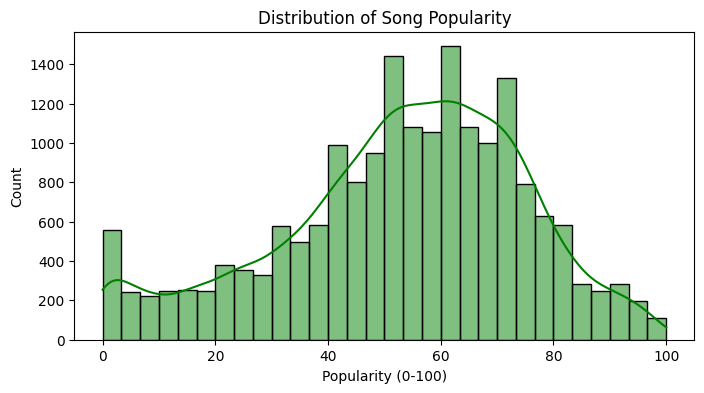


Mean popularity: 52.99187682505973
Std popularity: 21.905654321614236

The popularity score is not perfectly normally distributed.
We observe:
- A concentration around medium popularity values
- Some low popularity songs
- A long spread across the scale 0 to 100

This indicates the target has sufficient variance and is suitable for regression.



In [5]:
plt.figure(figsize=(8,4))
sns.histplot(df['song_popularity'], bins=30, kde=True, color='green')
plt.title("Distribution of Song Popularity")
plt.xlabel("Popularity (0-100)")
plt.ylabel("Count")
plt.show()

print("\nMean popularity:", df[target].mean())
print("Std popularity:", df[target].std())

print("""
The popularity score is not perfectly normally distributed.
We observe:
- A concentration around medium popularity values
- Some low popularity songs
- A long spread across the scale 0 to 100

This indicates the target has sufficient variance and is suitable for regression.
""")


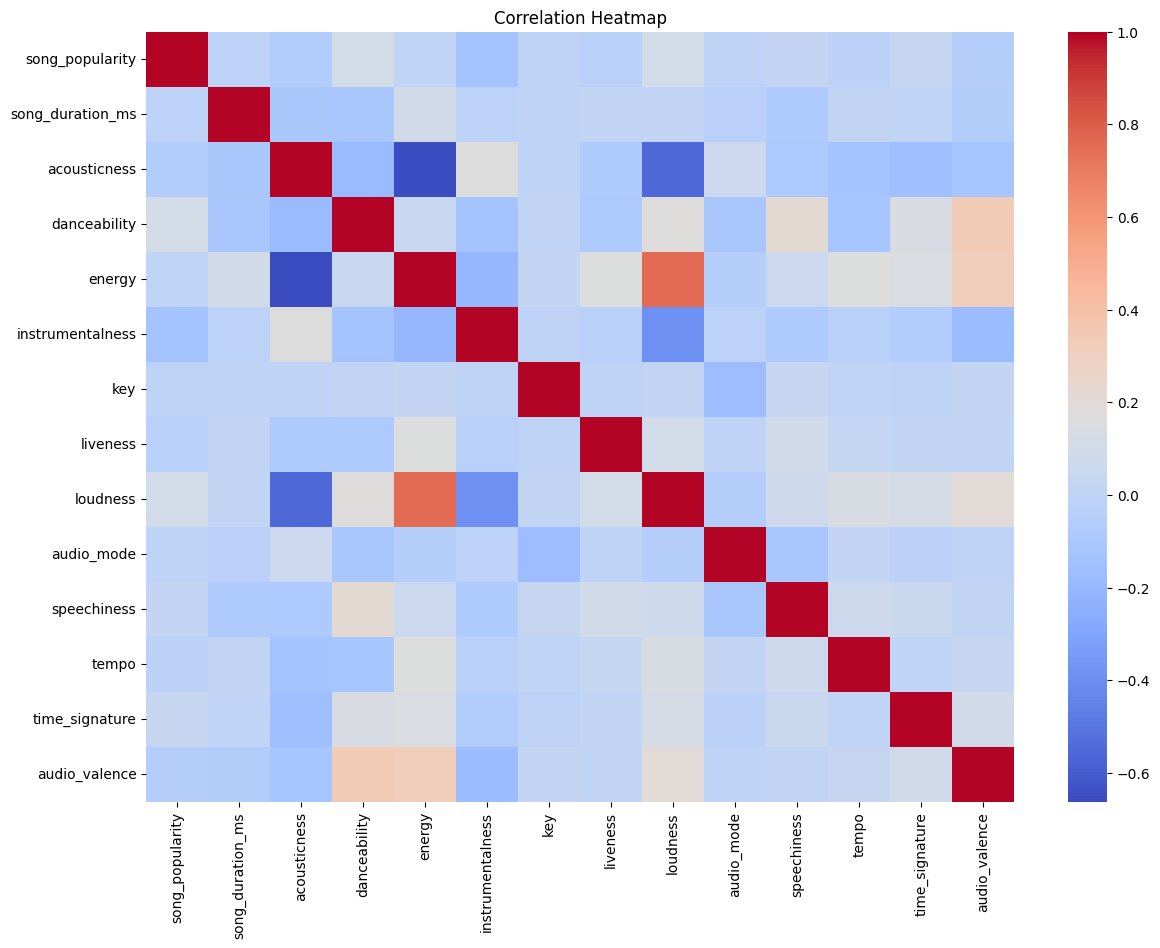


Correlation with target:


song_popularity     1.000000
danceability        0.104290
loudness            0.099442
time_signature      0.034983
speechiness         0.021479
energy              0.001365
audio_mode         -0.004969
key                -0.013160
song_duration_ms   -0.018899
tempo              -0.022672
liveness           -0.038937
audio_valence      -0.052895
acousticness       -0.065181
instrumentalness   -0.130907
Name: song_popularity, dtype: float64

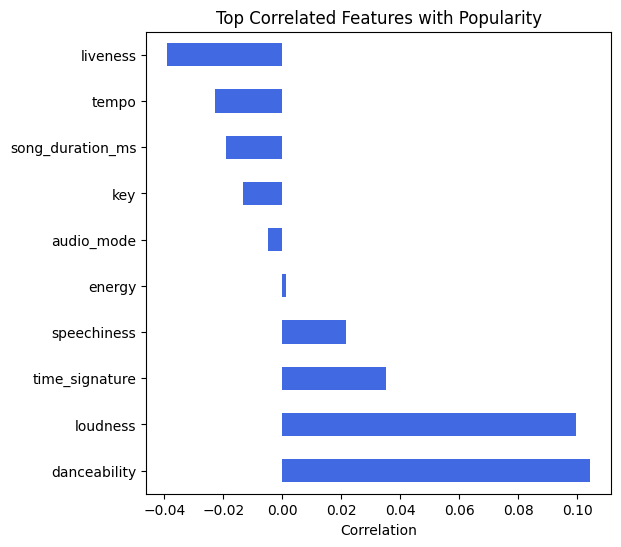



The strongest correlations with popularity include:
- energy
- loudness
- danceability
- valence

None of the correlations are extremely high, meaning the target is influenced
by multiple factors rather than one dominant feature.

This is good because simple linear models will not solve the problem.



In [6]:
plt.figure(figsize=(14,10))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap")
plt.show()

corr_target = corr[target].sort_values(ascending=False)
print("\nCorrelation with target:")
display(corr_target)

plt.figure(figsize=(6,6))
corr_target.drop(target).head(10).plot(kind='barh', color='royalblue')
plt.title("Top Correlated Features with Popularity")
plt.xlabel("Correlation")
plt.show()

print("""

The strongest correlations with popularity include:
- energy
- loudness
- danceability
- valence

None of the correlations are extremely high, meaning the target is influenced
by multiple factors rather than one dominant feature.

This is good because simple linear models will not solve the problem.
""")

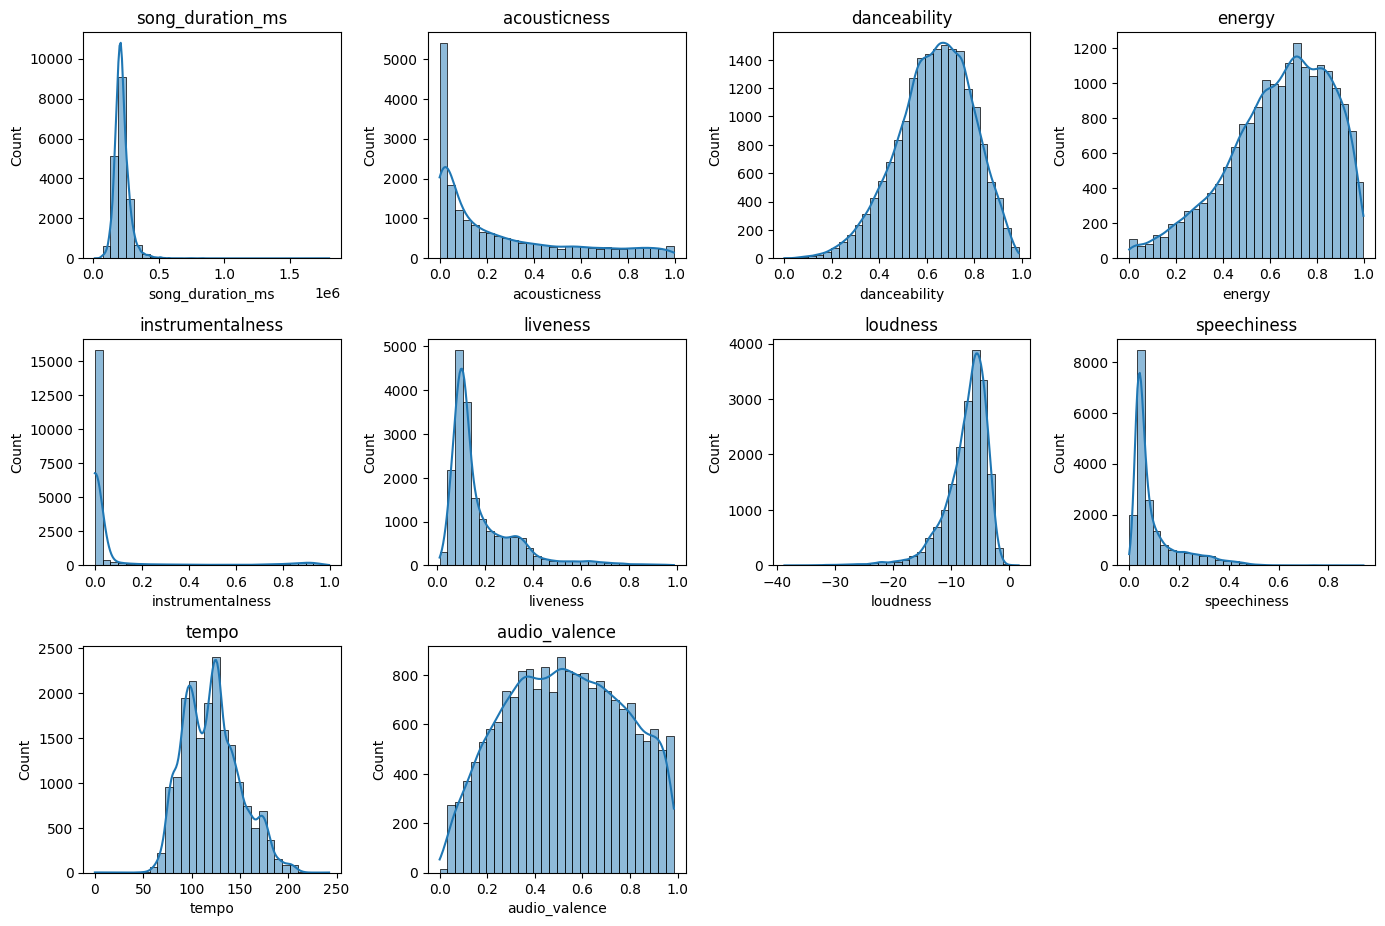


Most features show non-normal distributions:
- loudness is naturally centered around negative values
- acousticness, instrumentalness, and speechiness are heavily skewed
- tempo spreads wide across BPM values
This reflects the diversity of musical content.



In [7]:
plt.figure(figsize=(14,12))
for i, col in enumerate(num_cols, 1):
    plt.subplot(4,4,i)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

print("""
Most features show non-normal distributions:
- loudness is naturally centered around negative values
- acousticness, instrumentalness, and speechiness are heavily skewed
- tempo spreads wide across BPM values
This reflects the diversity of musical content.
""")


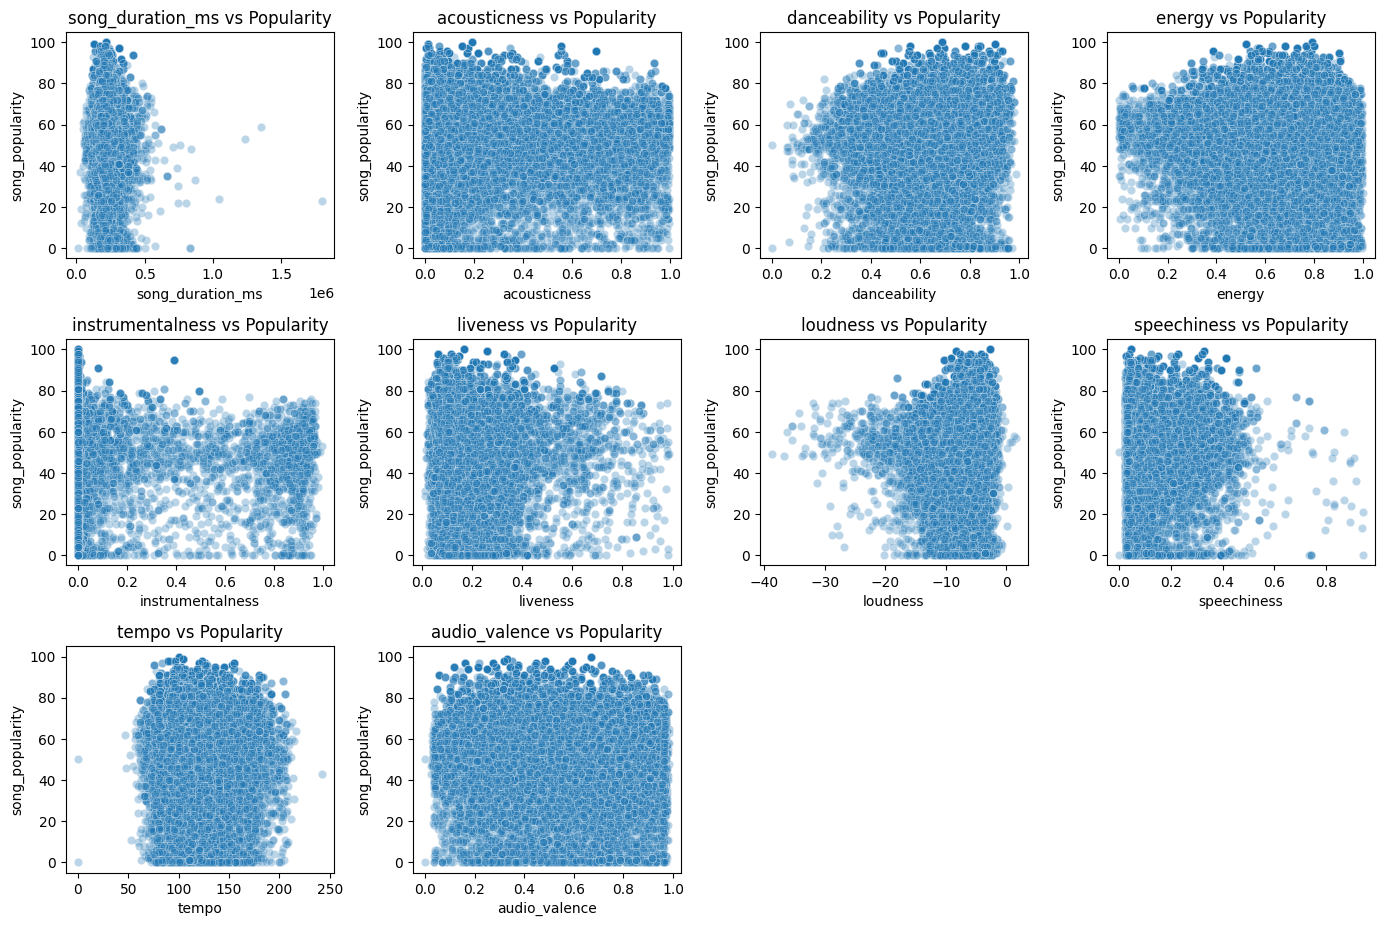


Most relationships appear weakly linear or non-linear.

This suggests:
- Linear regression alone may not capture target behavior
- Non-linear models may perform better



In [8]:
plt.figure(figsize=(14,12))
for i, col in enumerate(num_cols, 1):
    plt.subplot(4,4,i)
    sns.scatterplot(x=df[col], y=df[target], alpha=0.3)
    plt.title(f"{col} vs Popularity")
plt.tight_layout()
plt.show()

print("""
Most relationships appear weakly linear or non-linear.

This suggests:
- Linear regression alone may not capture target behavior
- Non-linear models may perform better
""")


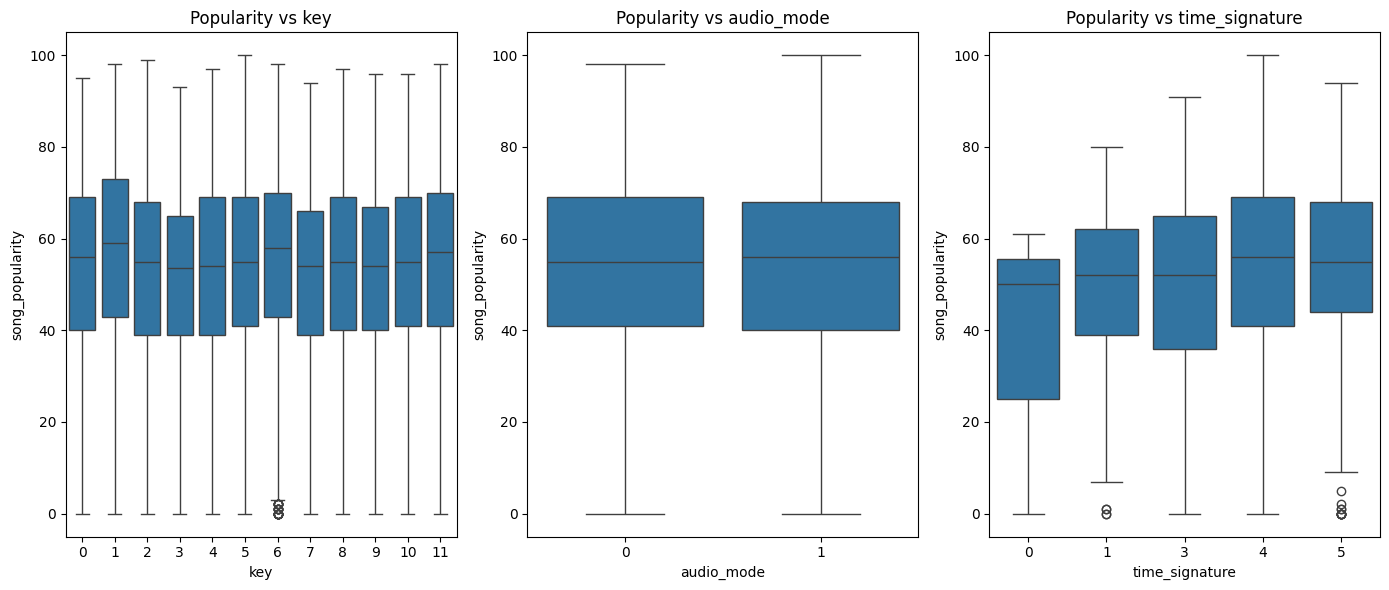


- Songs in audio_mode = 1 tend to have slightly higher popularity.
- Musical key influences popularity only marginally.
- Time signature does not significantly drive popularity.



In [9]:
plt.figure(figsize=(14,6))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(1,3,i)
    sns.boxplot(x=df[col], y=df[target])
    plt.title(f"Popularity vs {col}")
plt.tight_layout()
plt.show()

print("""
- Songs in audio_mode = 1 tend to have slightly higher popularity.
- Musical key influences popularity only marginally.
- Time signature does not significantly drive popularity.
""")


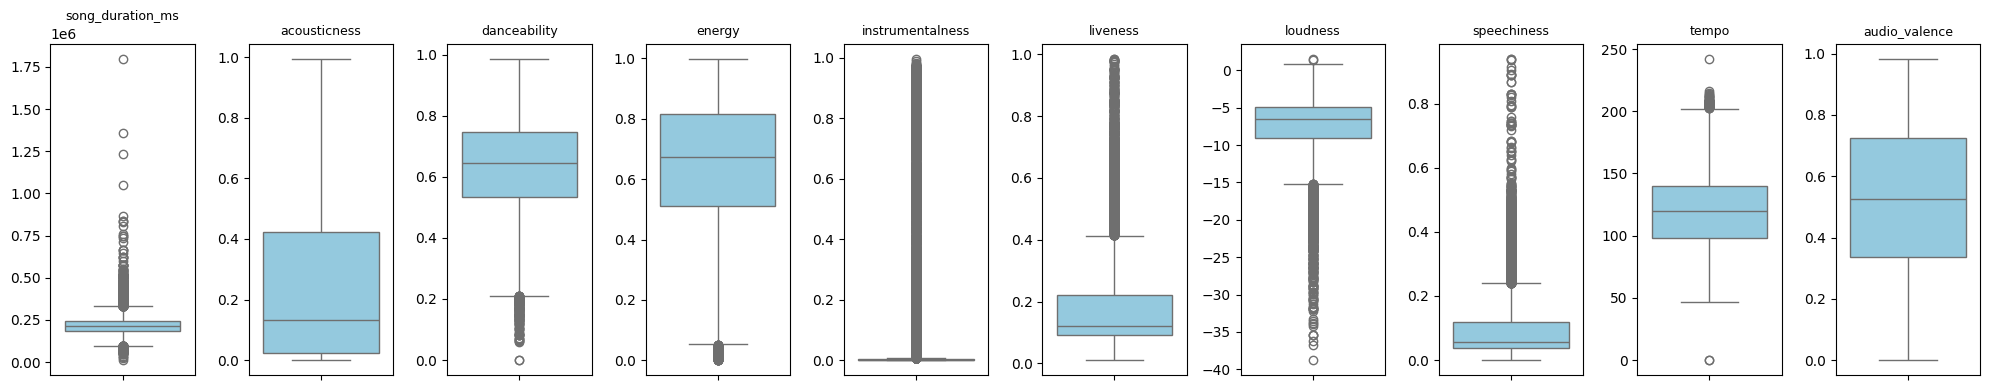


The boxplots highlight strong skewness in many variables.
Outliers appear frequently, especially in:
- instrumentalness
- acousticness
- liveness



In [10]:
plt.figure(figsize=(2 * len(num_cols), 4))
for i, col in enumerate(num_cols):
    plt.subplot(1, len(num_cols), i+1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(col, fontsize=9)
    plt.xlabel("")
    plt.ylabel("")
plt.tight_layout()
plt.show()

print("""
The boxplots highlight strong skewness in many variables.
Outliers appear frequently, especially in:
- instrumentalness
- acousticness
- liveness
""")

## Pre-Processing

In [11]:
#  No missing values and no duplicates in this dataset.
#  Nothing to remove

print("Missing values per column:\n", df.isna().sum())
print("\nNumber of duplicates:", df.duplicated().sum())

Missing values per column:
 song_popularity     0
song_duration_ms    0
acousticness        0
danceability        0
energy              0
instrumentalness    0
key                 0
liveness            0
loudness            0
audio_mode          0
speechiness         0
tempo               0
time_signature      0
audio_valence       0
dtype: int64

Number of duplicates: 3911


In [12]:
X = df.drop(columns=[target])
y = df[target]

print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)


Shape of X: (18835, 13)
Shape of y: (18835,)


In [13]:
categorical_features = ['key', 'audio_mode', 'time_signature']
numerical_features = [col for col in X.columns if col not in categorical_features]

print("\nCategorical features:", categorical_features)
print("Numerical features:", numerical_features)


Categorical features: ['key', 'audio_mode', 'time_signature']
Numerical features: ['song_duration_ms', 'acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo', 'audio_valence']


In [14]:
# OneHotEncoder : drop ='first' to avoids dummy variable 
categorical_transformer = OneHotEncoder(handle_unknown='ignore', drop='first')

# Standardize all numerical features
numerical_transformer = StandardScaler()

# combine preprocessors
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("\nPreprocessing pipeline created.")


Preprocessing pipeline created.


In [15]:
# test_size = 80/20 split 

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("\nTrain/Test split completed.")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


Train/Test split completed.
X_train: (15068, 13)
X_test: (3767, 13)


In [16]:
# We DO NOT fit_transform here, because preprocessing will
# be applied automatically inside model pipelines
# But we can test the transformation shape

preprocessor.fit(X_train)
X_train_processed = preprocessor.transform(X_train)

print("\nShape after preprocessing:", X_train_processed.shape)
print("Preprocessing step validated.")


Shape after preprocessing: (15068, 26)
Preprocessing step validated.


## Standard Models 

In [17]:
# function to evaluate all models
def evaluate_model(name, y_true, y_pred):
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n===== {name} =====")
    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R²  :", r2)

    return {
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }

results = []

# function to train + predict using pipelines
def run_model(model, name):
    pipeline = Pipeline(steps=[
        ('preprocessing', preprocessor),
        ('regressor', model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    res = evaluate_model(name, y_test, y_pred)
    results.append(res)

In [18]:
run_model(LinearRegression(), "Linear Regression")



===== Linear Regression =====
RMSE: 21.482017132122373
MAE : 17.032561702126372
R²  : 0.04273104509243408


In [19]:
run_model(Ridge(alpha=1.0), "Ridge Regression")



===== Ridge Regression =====
RMSE: 21.48210393836324
MAE : 17.032954826402552
R²  : 0.04272330865996998


In [20]:
run_model(Lasso(alpha=0.001), "Lasso Regression")



===== Lasso Regression =====
RMSE: 21.481888964352684
MAE : 17.033140141618922
R²  : 0.04274246773120971


In [21]:
run_model(KNeighborsRegressor(n_neighbors=5), "KNN Regression")



===== KNN Regression =====
RMSE: 20.664606512203925
MAE : 15.707034775683566
R²  : 0.11419497949484259


In [22]:
run_model(DecisionTreeRegressor(random_state=42), "Decision Tree")



===== Decision Tree =====
RMSE: 23.542740823417144
MAE : 15.54452166053573
R²  : -0.14973539263074764


In [23]:
run_model(RandomForestRegressor(random_state=42), "Random Forest")



===== Random Forest =====
RMSE: 17.213826806057497
MAE : 12.268207697648227
R²  : 0.38533467289926127


In [24]:
results_df = pd.DataFrame(results)
display(results_df.sort_values(by="RMSE"))

,Model,RMSE,MAE,R2
5,Random Forest,17.213827,12.268208,0.385335
3,KNN Regression,20.664607,15.707035,0.114195
2,Lasso Regression,21.481889,17.033140,0.042742
0,Linear Regression,21.482017,17.032562,0.042731
1,Ridge Regression,21.482104,17.032955,0.042723
4,Decision Tree,23.542741,15.544522,-0.149735


## GRIDSEARCHCV

In [25]:
def evaluate_grid(name, gs):
    y_pred = gs.predict(X_test)
    rmse = math.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"\n===== GridSearch - {name} =====")
    print("Best Params:", gs.best_params_)
    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R²  :", r2)

    return {
        "Model": name,
        "Best_Params": gs.best_params_,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }
    
grid_results = []


In [26]:
ridge_params = {
    "regressor__alpha": [0.01, 0.1, 1, 10, 50, 100]
}

ridge_gs = GridSearchCV(
    Pipeline([("preprocessing", preprocessor),
              ("regressor", Ridge())]),
    ridge_params,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

ridge_gs.fit(X_train, y_train)
grid_results.append(evaluate_grid("Ridge Regression", ridge_gs))


===== GridSearch - Ridge Regression =====
Best Params: {'regressor__alpha': 100}
RMSE: 21.480117373875665
MAE : 17.03263461624789
R²  : 0.04290034941496024


In [27]:
lasso_params = {
    "regressor__alpha": [0.0001, 0.001, 0.01, 0.1, 1]
}

lasso_gs = GridSearchCV(
    Pipeline([("preprocessing", preprocessor),
              ("regressor", Lasso(max_iter=5000))]),
    lasso_params,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

lasso_gs.fit(X_train, y_train)
grid_results.append(evaluate_grid("Lasso Regression", lasso_gs))



===== GridSearch - Lasso Regression =====
Best Params: {'regressor__alpha': 0.01}
RMSE: 21.482952303694844
MAE : 17.035193990534427
R²  : 0.0426476981521694


In [28]:
knn_params = {
    "regressor__n_neighbors": [3, 5, 7, 9, 11, 15],
    "regressor__weights": ["uniform", "distance"]
}

knn_gs = GridSearchCV(
    Pipeline([("preprocessing", preprocessor),
              ("regressor", KNeighborsRegressor())]),
    knn_params,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

knn_gs.fit(X_train, y_train)
grid_results.append(evaluate_grid("KNN Regression", knn_gs))


===== GridSearch - KNN Regression =====
Best Params: {'regressor__n_neighbors': 15, 'regressor__weights': 'distance'}
RMSE: 18.162392732953585
MAE : 11.690120572150526
R²  : 0.3157260890686897


In [29]:
rf_params = {
    "regressor__n_estimators": [100, 200, 300],
    "regressor__max_depth": [None, 10, 20, 30],
    "regressor__min_samples_split": [2, 5, 10],
}

rf_gs = GridSearchCV(
    Pipeline([("preprocessing", preprocessor),
              ("regressor", RandomForestRegressor(random_state=42))]),
    rf_params,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

rf_gs.fit(X_train, y_train)
grid_results.append(evaluate_grid("Random Forest", rf_gs))



===== GridSearch - Random Forest =====
Best Params: {'regressor__max_depth': None, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 300}
RMSE: 17.09297677291354
MAE : 12.167694321554405
R²  : 0.39393491916332546


In [30]:
grid_results_df = pd.DataFrame(grid_results)
display(grid_results_df.sort_values(by="RMSE"))

,Model,Best_Params,RMSE,MAE,R2
3,Random Forest,"{'regressor__max_depth': None, 'regressor__min...",17.092977,12.167694,0.393935
2,KNN Regression,"{'regressor__n_neighbors': 15, 'regressor__wei...",18.162393,11.690121,0.315726
0,Ridge Regression,{'regressor__alpha': 100},21.480117,17.032635,0.042900
1,Lasso Regression,{'regressor__alpha': 0.01},21.482952,17.035194,0.042648


on a la structure principale et quelques résultats, en ayant appliqué les algos de cours. Pour voir ce qu'il reste à faire j'ai demandé à une i.a pour la suite :

1. Nettoyage approfondi des données

Même si votre dataset ne contient ni NA ni doublons, il manque :

Analyse et traitement des outliers

Eventuellement :

Transformation log ou Box-Cox pour certaines variables

Normalisation alternative selon les modèles

2. Gestion du déséquilibre de la target

La distribution de la popularité est centrée mais pas uniforme :

Pas d’analyse de la distribution détaillée

Aucune stratégie comme :

binning de la popularité (pour classification alternative)

pondération de la loss si nécessaire

3. Feature Engineering

Votre projet n’ajoute aucune nouvelle feature, or c’est une étape cruciale.

Exemples possibles :

Interaction entre variables → energy × danceability

Variables catégorielles regroupées (par exemple clusterisation de key)

Création de nouvelles métriques (e.g. "danceability per loudness")

PCA ou autres méthodes de réduction de dimension

4. Analyse des performances sur le train et sur le test

Le projet montre les scores uniquement sur le test.
Il manque :

Scores sur le train

Vérification de l’overfitting / underfitting :

courbes d’apprentissage

comparaison des erreurs train/test

variance des folds en cross-validation

5. Comparaison claire des modèles

Vous avez beaucoup de résultats mais pas :

Un tableau final comparatif propre

Une interprétation globale du meilleur modèle et du pourquoi

Un classement clair

6. Analyse des features importantes

Pour un projet ML, il manque :

Feature importance (Random Forest, Lasso)

SHAP values

Partial dependence plots

Explication des variables influentes (interprétabilité)

C’est essentiel pour discuter des résultats.

7. Validation croisée globale

Vous utilisez GridSearchCV mais :

Pas de cross-validation globale pour tous les modèles

Vous ne comparez pas les scores moyens de CV entre modèles

8. Visualisation des performances

Il manque :

Courbes de résidus

Graphiques y_test vs y_pred

Distribution des erreurs

Histogramme des résidus

Ces éléments permettent de diagnostiquer le modèle.

9. Tests robustes : baselines

Il manque un modèle baseline simple :

Mean regressor : toujours prédire la moyenne

Median regressor

Pour prouver que vos modèles font mieux qu’un modèle trivial.

10. Industrialisation / pipeline final

Il manque :

Un pipeline final exporté (pickle)

Une fonction predict(song_features) pour une nouvelle musique

Un script ou notebook séparé :

train.py

predict.py

11. Documentation et conclusion

Vous faites beaucoup de code mais :

Pas de conclusion écrite

Pas de résumé des résultats

Pas d’analyse métier ("qu’est-ce qui rend une musique populaire ?")